In [1]:
from PIL import Image
import numpy as np
import random
random.seed(10)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pickle
import matplotlib.cm as cm
from matplotlib.colors import Normalize

In [10]:

def visualize_patch_centers(image, centers, patch_size):
    fig, ax = plt.subplots(1, figsize=(8,8))
    
    image_np = np.array(image)
    if image_np.max() > 1:
        image_np = image_np / 255.0
    
    ax.imshow(image_np)
    
    patch_height, patch_width = patch_size
    n = len(centers)
    
    cmap = cm.get_cmap("viridis", n)
    norm = Normalize(vmin=0, vmax=n-1)
    
    for idx, (w, h) in enumerate(centers):
        color = cmap(norm(idx))
        
        rect = patches.Rectangle(
            (w - patch_width // 2, h - patch_height // 2), 
            patch_width, patch_height,
            linewidth=1, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.plot(w, h, marker='o', color=color, markersize=3)
    
    ax.set_xlim([0, image_np.shape[1]])
    ax.set_ylim([image_np.shape[0], 0])
    plt.axis('off')
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Ordem dos patches")
    
    plt.show()

In [10]:
def arround_patch(first_path: tuple, step: int, nivel: int):

    arround_centers = []
    x_start, y_start = first_path[0] - step, first_path[1] + step

    arround_centers.append((x_start, y_start))

    soma = lambda x, y: x + y
    sub = lambda x, y: x - y
    nothing = lambda x, y: x
    for i in range(
        0,
        4,
    ):
        operacao_x = soma if i == 0 else sub if i == 2 else nothing
        operacao_y = sub if i == 1 else soma if i == 3 else nothing

        if i % 2 == 0:
            for _ in range(0, nivel):
                last_x, last_y = arround_centers[-1]
                arround_centers.append(
                    (operacao_x(last_x, step), operacao_y(last_y, step))
                )
        else:
            for _ in range(0, nivel):
                last_x, last_y = arround_centers[-1]
                arround_centers.append(
                    (operacao_x(last_x, step), operacao_y(last_y, step))
                )
    return arround_centers


def calculate_coords_espiral_sem_sobre(img_size: tuple, patch_size: tuple, patch_qtd: int):
    largura = img_size[0] // 2
    altura = img_size[0] // 2
    center = (largura, altura)
    center_list = [center]
    nivel = 2
    while len(center_list) < patch_qtd:
      center_list.extend(
          arround_patch(center_list[-1], patch_size[0], nivel)
      )
      nivel += 2
      str("")

    if len(center_list) >= patch_qtd:
        for i in range(len(center_list) - 1, patch_qtd - 2, -1):
            center_list.pop(i)

    return center_list

In [2]:
path_image = "../data/base_recortada/ASC-H/10.png"
im = Image.open(path_image)
im.format, im.size, im.mode

('PNG', (90, 90), 'RGB')

In [ ]:
centers_list = calculate_coords_espiral_sem_sobre((224,224), (16,16), 196)
len(centers_list)

/tmp/ipykernel_5951/2611782670.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis", n)


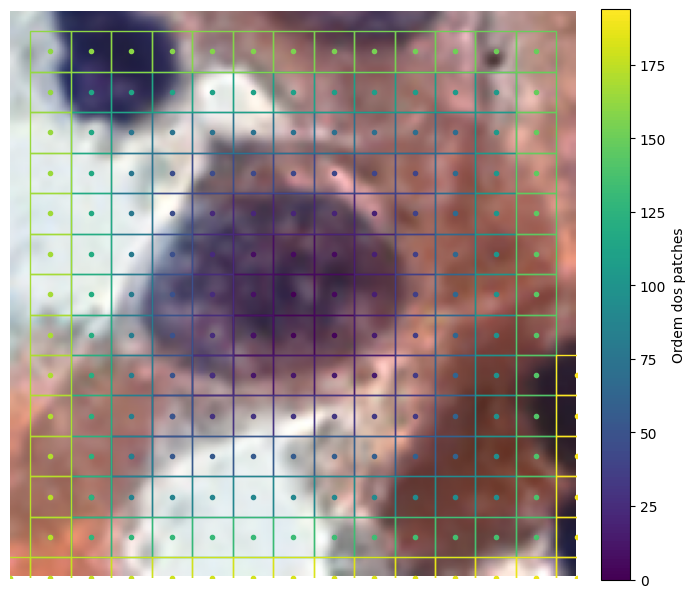

In [81]:
resized_image = im.resize((224,224))
visualize_patch_centers(resized_image, centers_list, (16,16))

In [4]:
def grid_centers(img_size, patch_size):
    W, H = img_size
    pw, ph = patch_size
    centers = []
    for y in range(ph//2, H, ph):
        for x in range(pw//2, W, pw):
            centers.append((x,y))
    return centers

centers = grid_centers((224,224), (16,16))
len(centers), print(centers)


[(8, 8), (24, 8), (40, 8), (56, 8), (72, 8), (88, 8), (104, 8), (120, 8), (136, 8), (152, 8), (168, 8), (184, 8), (200, 8), (216, 8), (8, 24), (24, 24), (40, 24), (56, 24), (72, 24), (88, 24), (104, 24), (120, 24), (136, 24), (152, 24), (168, 24), (184, 24), (200, 24), (216, 24), (8, 40), (24, 40), (40, 40), (56, 40), (72, 40), (88, 40), (104, 40), (120, 40), (136, 40), (152, 40), (168, 40), (184, 40), (200, 40), (216, 40), (8, 56), (24, 56), (40, 56), (56, 56), (72, 56), (88, 56), (104, 56), (120, 56), (136, 56), (152, 56), (168, 56), (184, 56), (200, 56), (216, 56), (8, 72), (24, 72), (40, 72), (56, 72), (72, 72), (88, 72), (104, 72), (120, 72), (136, 72), (152, 72), (168, 72), (184, 72), (200, 72), (216, 72), (8, 88), (24, 88), (40, 88), (56, 88), (72, 88), (88, 88), (104, 88), (120, 88), (136, 88), (152, 88), (168, 88), (184, 88), (200, 88), (216, 88), (8, 104), (24, 104), (40, 104), (56, 104), (72, 104), (88, 104), (104, 104), (120, 104), (136, 104), (152, 104), (168, 104), (184, 

(196, None)

In [42]:
def spiral_order(centers, img_size, patch_size):
    W, H = img_size
    pw, ph = patch_size
    cx, cy = W//2, H//2

    cx = (cx // pw) * pw + pw//2
    cy = (cy // ph) * ph + ph//2

    centers_set = set(centers)
    order = []

    max_r = max(W//pw, H//ph)
    step = pw

    if (cx, cy) in centers_set:
      order.append((cx, cy))
      centers_set.remove((cx,cy))
    
    for r in range(1, max_r):
        x, y = cx - r*step, cy + r*step
        
        for _ in range(2*r):
            x += step
            if (x,y) in centers_set: order.append((x,y))
        
        for _ in range(2*r):
            y -= step
            if (x,y) in centers_set: order.append((x,y))
        
        for _ in range(2*r):
            x -= step
            if (x,y) in centers_set: order.append((x,y))
        
        for _ in range(2*r):
            y += step
            if (x,y) in centers_set: order.append((x,y))

    return order

grid = grid_centers((224,224), (16,16))
spiral_nova = spiral_order(centers, (224,224), (16,16))
len(spiral_nova)


196

In [6]:
spiral_nova[:5], centers[:5]

([(120, 120), (120, 136), (136, 136), (136, 120), (136, 104)],
 [(8, 8), (24, 8), (40, 8), (56, 8), (72, 8)])

In [7]:
index_list = []

for i in range(0, len(spiral_nova)):
  for idx, j in enumerate(range(0, len(centers))):
    if centers[j] == spiral_nova[i]:
      index_list.append((idx, spiral_nova[i]))
      
index_list

[(105, (120, 120)),
 (119, (120, 136)),
 (120, (136, 136)),
 (106, (136, 120)),
 (92, (136, 104)),
 (91, (120, 104)),
 (90, (104, 104)),
 (104, (104, 120)),
 (118, (104, 136)),
 (132, (104, 152)),
 (133, (120, 152)),
 (134, (136, 152)),
 (135, (152, 152)),
 (121, (152, 136)),
 (107, (152, 120)),
 (93, (152, 104)),
 (79, (152, 88)),
 (78, (136, 88)),
 (77, (120, 88)),
 (76, (104, 88)),
 (75, (88, 88)),
 (89, (88, 104)),
 (103, (88, 120)),
 (117, (88, 136)),
 (131, (88, 152)),
 (145, (88, 168)),
 (146, (104, 168)),
 (147, (120, 168)),
 (148, (136, 168)),
 (149, (152, 168)),
 (150, (168, 168)),
 (136, (168, 152)),
 (122, (168, 136)),
 (108, (168, 120)),
 (94, (168, 104)),
 (80, (168, 88)),
 (66, (168, 72)),
 (65, (152, 72)),
 (64, (136, 72)),
 (63, (120, 72)),
 (62, (104, 72)),
 (61, (88, 72)),
 (60, (72, 72)),
 (74, (72, 88)),
 (88, (72, 104)),
 (102, (72, 120)),
 (116, (72, 136)),
 (130, (72, 152)),
 (144, (72, 168)),
 (158, (72, 184)),
 (159, (88, 184)),
 (160, (104, 184)),
 (161, (120

In [119]:
with open("../data/centros_pre_salvos/espiral_sem_sobrepoisicao_INDEX.pkl", "wb") as file:
  pickle.dump(index_list, file)

In [8]:
spiral_nova[0], centers[0]

((120, 120), (8, 8))

/tmp/ipykernel_1593/2611782670.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis", n)


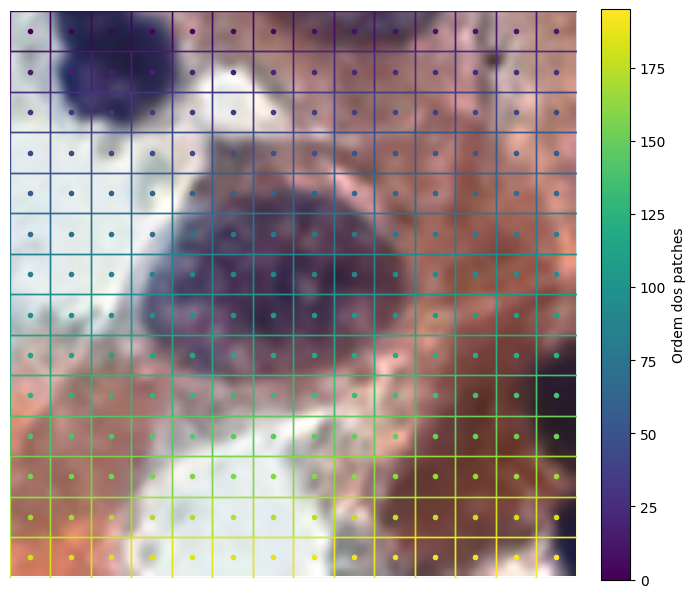

In [11]:
resized_image = im.resize((224,224))
visualize_patch_centers(resized_image, centers, (16,16))

/tmp/ipykernel_1593/2611782670.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis", n)


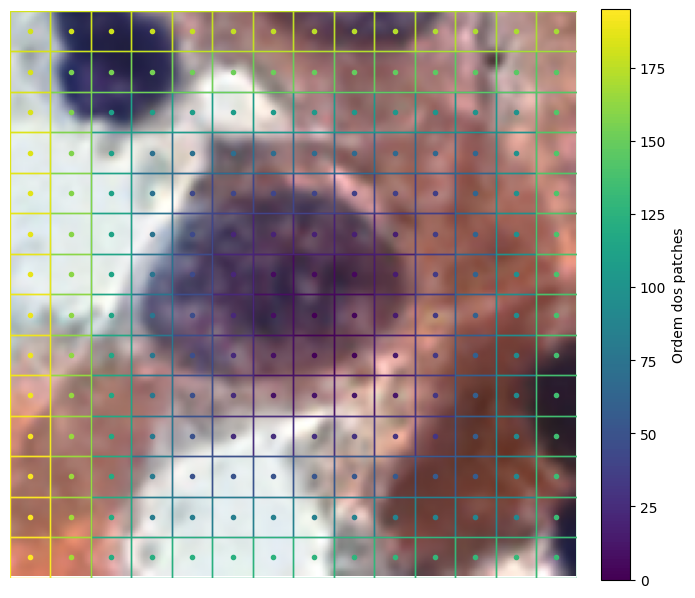

In [41]:
visualize_patch_centers(resized_image, spiral_nova, (16,16))

In [35]:
spiral_nova[-1]

(8, 216)

In [18]:
from IPython.display import clear_output
import time

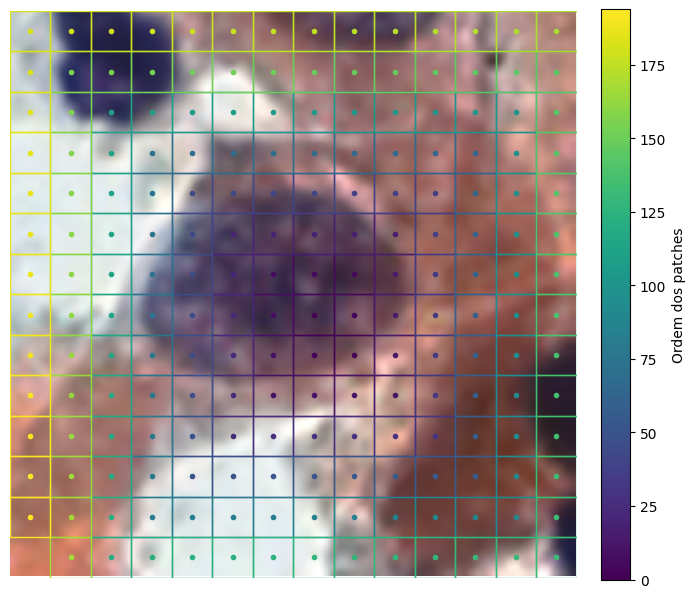

In [43]:
resized_image = im.resize((224,224))
for i in range(1, 196):
  visualize_patch_centers(resized_image, spiral_nova[:i], (16,16))
  clear_output(True)
  # time.sleep(0.8)
  

In [13]:
cont = 0
element_list = []
for each in spiral:
  
  if each in element_list:
    cont +=1
  element_list.append(each)

In [14]:
cont, len(element_list)

(0, 196)

In [20]:
for each in zip(centers, spiral):
  print( each[1])

(120, 120)
(120, 136)
(136, 136)
(136, 120)
(136, 104)
(120, 104)
(104, 104)
(104, 120)
(104, 136)
(104, 152)
(120, 152)
(136, 152)
(152, 152)
(152, 136)
(152, 120)
(152, 104)
(152, 88)
(136, 88)
(120, 88)
(104, 88)
(88, 88)
(88, 104)
(88, 120)
(88, 136)
(88, 152)
(88, 168)
(104, 168)
(120, 168)
(136, 168)
(152, 168)
(168, 168)
(168, 152)
(168, 136)
(168, 120)
(168, 104)
(168, 88)
(168, 72)
(152, 72)
(136, 72)
(120, 72)
(104, 72)
(88, 72)
(72, 72)
(72, 88)
(72, 104)
(72, 120)
(72, 136)
(72, 152)
(72, 168)
(72, 184)
(88, 184)
(104, 184)
(120, 184)
(136, 184)
(152, 184)
(168, 184)
(184, 184)
(184, 168)
(184, 152)
(184, 136)
(184, 120)
(184, 104)
(184, 88)
(184, 72)
(184, 56)
(168, 56)
(152, 56)
(136, 56)
(120, 56)
(104, 56)
(88, 56)
(72, 56)
(56, 56)
(56, 72)
(56, 88)
(56, 104)
(56, 120)
(56, 136)
(56, 152)
(56, 168)
(56, 184)
(56, 200)
(72, 200)
(88, 200)
(104, 200)
(120, 200)
(136, 200)
(152, 200)
(168, 200)
(184, 200)
(200, 200)
(200, 184)
(200, 168)
(200, 152)
(200, 136)
(200, 120)
(